# Multi-Layer Perceptron: Solving XOR Problem


## 1. Introduction

A single neuron can only learn **linear decision boundaries**.

In the previous notebook, we saw that a single neuron successfully solved the **AND** and **OR** problems, but it failed on the **XOR** problem because XOR is **not linearly separable**.

To solve more complex problems, we combine multiple neurons together into layers. This creates a **Multi-Layer Perceptron (MLP)**, which is the basic structure behind modern Artificial Neural Networks (ANNs).

A Multi-Layer Perceptron consists of:

- **Input Layer**: Receives the input features.
- **Hidden Layer(s)**: Learns intermediate representations and non-linear patterns.
- **Output Layer**: Produces the final prediction.

The hidden layers allow the network to learn complex relationships that cannot be represented by a single straight line.

---

### Network Architecture

For solving the XOR problem, we will build the following network:

    Input Layer [2 Features]
            |
            |
    Hidden Layer [4 Neurons (ReLU)]
            |
            |
    Output Layer [1 Neuron (Sigmoid)]
            |


---

### 3. Mathematical Representation

A neural network performs several transformations between layers.

## Hidden Layer

First, the hidden layer calculates a weighted sum of inputs:

$$
z^{(1)} = W^{(1)}X + b^{(1)}
$$


Where:

- $W^{(1)}$ → weights of the hidden layer
- $X$ → input features
- $b^{(1)}$ → bias of the hidden layer
- $z^{(1)}$ → linear combination before activation


Then the activation function is applied:

$$
a^{(1)} = ReLU(z^{(1)})
$$


The ReLU activation function is:

$$
ReLU(x)=max(0,x)
$$


---

### Output Layer

The output layer receives the hidden representation:

$$
z^{(2)} = W^{(2)}a^{(1)} + b^{(2)}
$$


Then the sigmoid activation converts the value into a probability:

$$
\hat{y} = \sigma(z^{(2)})
$$


where:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$


The final output represents the predicted class:

- $\hat{y} \approx 0$ → Class 0
- $\hat{y} \approx 1$ → Class 1

## 2. Import Libaries

In [23]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## 3. XOR Dataset

In [24]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])


y = np.array([
    0,
    1,
    1,
    0
])

## 4. Build MLP Model

In [25]:
model = Sequential(
    [
       Dense(
            units= 4,
            activation= tf.keras.activations.relu,
            input_shape=(2,)
       ),
       Dense(
           units=1 ,
           activation=  tf.keras.activations.sigmoid
       )
    ]
)

## 5. Compile Model

In [26]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 6. Train Model

In [27]:
history = model.fit(
    X,
    y,
    epochs=1000,
    verbose=0
)

## 7. Evaluate Model

In [28]:
loss, acc = model.evaluate(
    X,
    y
)

print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 1.0000 - loss: 0.2700
Accuracy: 1.0


## 8. Predictions

In [29]:
predictions = model.predict(X)

print(predictions)
print((predictions > 0.5).astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.29972547]
 [0.726071  ]
 [0.8172436 ]
 [0.1826923 ]]
[[0]
 [1]
 [1]
 [0]]


## 9. Plot Training Loss

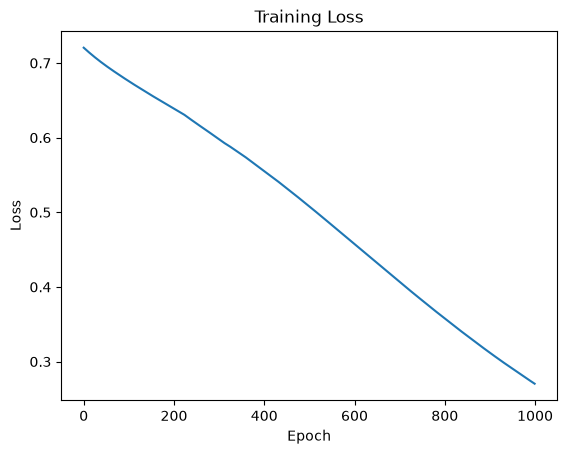

In [30]:
plt.plot(history.history["loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

## 10.Visualize Decision Boundary

In [31]:
def plot_decision_boundary(model, X, y, title):

    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5


    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,200),
        np.linspace(y_min,y_max,200)
    )


    grid = np.c_[
        xx.ravel(),
        yy.ravel()
    ]


    predictions = model.predict(
        grid,
        verbose=0
    )


    predictions = predictions.reshape(xx.shape)


    plt.figure(figsize=(6,5))


    plt.contourf(
        xx,
        yy,
        predictions,
        levels=[0,0.5,1],
        alpha=0.3
    )


    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        s=100,
        edgecolors="black"
    )


    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.title(title)

    plt.grid()

    plt.show()

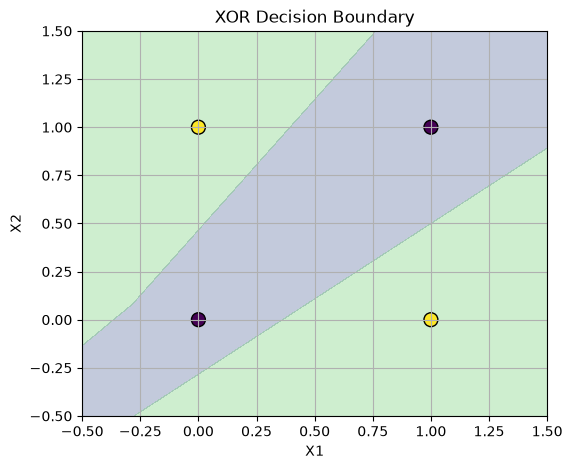

In [32]:
plot_decision_boundary(
    model,
    X,
    y,
    "XOR Decision Boundary"
)

## 11.Inspect Weights
    Explain:

    First layer learns intermediate features.
    Second layer combines those features to classify XOR.

In [33]:
for layer in model.layers:
    print(layer.get_weights())

[array([[ 1.6891984 ,  1.1445872 ,  1.4639987 , -1.7205932 ],
       [-1.6893777 , -1.1448689 , -0.45050362,  1.7204951 ]],
      dtype=float32), array([-1.5744142e-04,  3.5949386e-05,  4.5082337e-01,  2.5498765e-04],
      dtype=float32)]
[array([[ 1.0680385 ],
       [ 1.2937605 ],
       [-0.6408248 ],
       [ 0.89203227]], dtype=float32), array([-0.55998063], dtype=float32)]


## 12. Conclusion

# Conclusion

A single neuron can only learn linear relationships.

By adding a hidden layer, the network can learn non-linear representations.

Results:

| Model | XOR |
|---|---|
| Single Neuron | ❌ Failed |
| Multi-Layer Perceptron | ✅ Solved |

This is the basic idea behind deeper neural networks.